<a href="https://colab.research.google.com/github/Nifdi01/chest-xray-impact-analysis/blob/main/MAIN_TRAINING_NOTEBOOK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NOTEBOOK.
import kagglehub
khanfashee_nih_chest_x_ray_14_224x224_resized_path = kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')

print('Data source import complete.')

100%|██████████| 2.30G/2.30G [00:28<00:00, 85.4MB/s]

Extracting files...


Data source import complete.


# Download Dependencies and Setup

In [ ]:
!pip install wandb -qU

# Data Preparation and Splitting

## Import Dependencies

In [ ]:
import os
import wandb
import random
import warnings

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import albumentations as A
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR


import timm
from timm.data import create_transform

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

## Setup for Reproducability

In [ ]:
def set_seed(seed=42):
    """
    Sets all seeds for reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU setups

    # Critical for CuDNN reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seeds set to {seed} for reproducibility.")

set_seed(42)

Seeds set to 42 for reproducibility.


## Define Constants and Paths

In [ ]:
# Define dataset paths for the Kaggle environment
DATA_DIR = khanfashee_nih_chest_x_ray_14_224x224_resized_path
CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'images-224/images-224/')

# 14 Pathology classes evaluated in ChestX-ray14
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

## Load the Dataset

In [ ]:
df = pd.read_csv(CSV_PATH)

# Add full image path for the PyTorch dataloader later
df['Image_Path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

print(f"Total records loaded: {len(df)}")
df.head()

Total records loaded: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Image_Path
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN,/root/.cache/kagglehub/datasets/khanfashee/nih...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN,/root/.cache/kagglehub/datasets/khanfashee/nih...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN,/root/.cache/kagglehub/datasets/khanfashee/nih...
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN,/root/.cache/kagglehub/datasets/khanfashee/nih...
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN,/root/.cache/kagglehub/datasets/khanfashee/nih...


## Preprocess and Binarize Labels

In [ ]:
# Split the pipe-separated strings into lists, handling 'No Finding' as an empty list
df['Labels'] = df['Finding Labels'].apply(lambda x: x.split('|') if x != 'No Finding' else [])

# Initialize and fit the binarizer for the 14 specific diseases
mlb = MultiLabelBinarizer(classes=DISEASES)
encoded_labels = mlb.fit_transform(df['Labels'])

# Append encoded labels as new columns to the dataframe
for i, disease in enumerate(DISEASES):
    df[disease] = encoded_labels[:, i]

df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,...,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,...,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112115,00030801_001.png,Mass|Pneumonia,1,30801,039Y,M,PA,2048,2500,0.168,...,0,0,0,0,0,1,0,0,1,0
112116,00030802_000.png,No Finding,0,30802,029Y,M,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
112117,00030803_000.png,No Finding,0,30803,042Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0
112118,00030804_000.png,No Finding,0,30804,030Y,F,PA,2048,2500,0.168,...,0,0,0,0,0,0,0,0,0,0


## Patient-Wise Splitting

In [ ]:
# Initialize GroupShuffleSplit for the first split (Hold out 20% for Testing)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 1. Split into (Train+Val) and Test
train_val_idx, test_idx = next(gss_test.split(df, groups=df['Patient ID']))
train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Initialize a second GroupShuffleSplit for the Train/Val split
# Following the paper: 80% of the remaining data forms the training split
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 2. Split (Train+Val) into Train and Validation
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['Patient ID']))
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Total distinct patients: {df['Patient ID'].nunique()}")
print(f"Training images: {len(train_df)} ({(len(train_df)/len(df))*100:.1f}%)")
print(f"Validation images: {len(val_df)} ({(len(val_df)/len(df))*100:.1f}%)")
print(f"Testing images: {len(test_df)} ({(len(test_df)/len(df))*100:.1f}%)")

# Verify absolutely no patient overlap across any of the three sets
train_patients = set(train_df['Patient ID'])
val_patients = set(val_df['Patient ID'])
test_patients = set(test_df['Patient ID'])

assert len(train_patients.intersection(val_patients)) == 0, "Leakage: Train/Val overlap"
assert len(train_patients.intersection(test_patients)) == 0, "Leakage: Train/Test overlap"
assert len(val_patients.intersection(test_patients)) == 0, "Leakage: Val/Test overlap"

print("Verification passed: No patient overlap across Train, Validation, and Test sets.")

Total distinct patients: 30805
Training images: 72061 (64.3%)
Validation images: 17765 (15.8%)
Testing images: 22294 (19.9%)
Verification passed: No patient overlap across Train, Validation, and Test sets.


# Dataset and DataLoaders

## Define Image Transformations

In [ ]:
# Calculate frequencies of each disease in the TRAINING set
label_counts = train_df[DISEASES].sum()
median_count = label_counts.median()

# Identify which labels fall below the median count
minority_labels = label_counts[label_counts < median_count].index.tolist()

print(f"Median label count: {median_count}")
print(f"Minority labels identified: {minority_labels}")

# Flag images in the training set that contain AT LEAST ONE minority label
# (This assumes your label columns contain 1s and 0s)
train_df['Apply_Augmentation'] = train_df[minority_labels].sum(axis=1) > 0

print(f"Images to augment: {train_df['Apply_Augmentation'].sum()} out of {len(train_df)}")

Median label count: 2600.5
Minority labels identified: ['Cardiomegaly', 'Edema', 'Emphysema', 'Fibrosis', 'Hernia', 'Pleural_Thickening', 'Pneumonia']
Images to augment: 8275 out of 72061


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224

print("Building train, validation, and test transforms...")

train_transform = A.Compose([
    # --- Geometric transforms ---
    A.HorizontalFlip(p=0.5),

    A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.7),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=0,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5,
    ),

    A.ElasticTransform(alpha=40, sigma=50, p=0.15),

    # --- Intensity transforms ---
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.7),

    A.RandomGamma(gamma_limit=(80, 120), p=0.3),

    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),

    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),

    # --- Random cutoffs (small occlusions <15%) ---
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(10, 30),
        hole_width_range=(10, 30),
        fill=0,
        p=0.3
    ),

    # --- Resize + normalize + tensor ---
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

data_transforms = {
    "train": train_transform,
    "val": val_test_transform,
    "test": val_test_transform
}

print("Transformations successfully updated.")

Building train, validation, and test transforms...
Transformations successfully updated.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Create the Custom PyTorch Dataset Class

In [ ]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): The train or validation dataframe.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.dataframe = dataframe
        self.transform = transform
        self.image_paths = dataframe['Image_Path'].values
        # Extract the 14 disease columns as a numpy array for fast access
        self.labels = dataframe[DISEASES].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Load the image
        img_path = self.image_paths[idx]

        # Convert grayscale X-rays to RGB as required by the Swin Transformer
        image = np.array(Image.open(img_path).convert('RGB'))

        # 2. Apply transformations
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]  # Extract the tensor from the dict

        # 3. Get the labels and convert to a PyTorch FloatTensor
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return image, label

## Custom Sampler for Dynamic Augmentation

In [ ]:
def build_mixed_sampler(df, smoothed_aucs, diseases, mix_alpha=0.7):
    difficulty = np.clip(1.0 - smoothed_aucs, 0.05, 0.5)
    difficulty = np.sqrt(difficulty)

    # Matrix multiply: (N, C) x (C,) → (N,) in one shot
    label_matrix = df[diseases].values                        # (N, C)
    diff_weights = label_matrix @ difficulty                  # (N,)

    # Samples with no positive label get baseline weight 1.0
    diff_weights = np.where(diff_weights == 0, 1.0, diff_weights)

    final_weights = mix_alpha * diff_weights + (1 - mix_alpha)

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(final_weights),
        num_samples=len(final_weights),
        replacement=True,
    )

## Instantiate Datasets and DataLoaders

In [ ]:
EMA_ALPHA = 0.3
MIX_ALPHA = 0.5


smoothed_aucs = np.full(len(DISEASES), 0.5, dtype=np.float64)

best_val_auroc = 0.0
model_save_path = "best_model.pth"

# Define batch size
BATCH_SIZE = 32  # Warning: Consider lowering to 32/64 if CUDA Out of Memory occurs


train_dataset = ChestXrayDataset(train_df, transform=data_transforms['train'])
val_dataset = ChestXrayDataset(val_df, transform=data_transforms['val'])
test_dataset = ChestXrayDataset(test_df, transform=data_transforms['test'])

sampler = build_mixed_sampler(train_df, smoothed_aucs, DISEASES, MIX_ALPHA)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # No need to shuffle test data
    num_workers=4,
    pin_memory=True
)

print(f"DataLoaders created. Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

# Quick sanity check
sample_images, sample_labels = next(iter(train_loader))
print(f"Sample image batch shape: {sample_images.shape}")
print(f"Sample label batch shape: {sample_labels.shape}")

DataLoaders created. Batch size: 32
Training batches: 2252
Validation batches: 556
Testing batches: 697
Sample image batch shape: torch.Size([32, 3, 224, 224])
Sample label batch shape: torch.Size([32, 14])


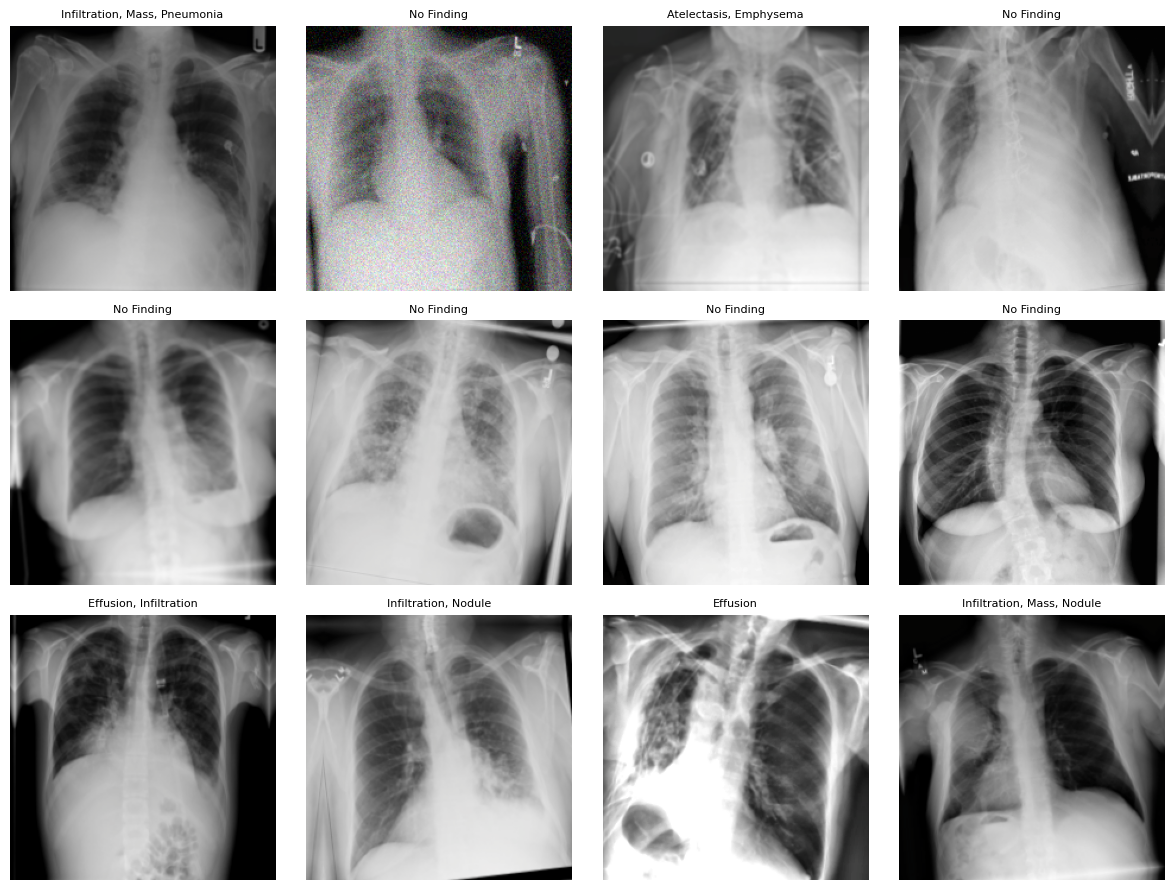

In [ ]:
def visualize_train_samples(train_loader, class_names):
    images, labels = next(iter(train_loader))
    images = images.cpu()
    labels = labels.cpu()

    # 1. Define ImageNet stats as tensors reshaped for batch broadcasting (1, C, 1, 1)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    # 2. Correctly reverse the ImageNet normalization
    images = images * std + mean

    # 3. Clamp values to [0, 1] to ensure matplotlib doesn't complain about floating point rounding errors
    images = torch.clamp(images, 0, 1)

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.flatten()

    for i in range(12):
        img = images[i]

        # Move channel dimension to the end for matplotlib (C, H, W) -> (H, W, C)
        img_np = img.permute(1, 2, 0).numpy()

        # Plot RGB
        axes[i].imshow(img_np)

        # Handle NIH multi-label parsing
        active = torch.where(labels[i] >= 0.5)[0]

        if active.numel() == 0:
            label_text = "No Finding"
        else:
            label_text = ", ".join([class_names[j] for j in active.tolist()])

        axes[i].set_title(label_text, fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run the updated visualizer
visualize_train_samples(train_loader, class_names=DISEASES)

# Model Architecture

## Main CheXNet Architecture

In [ ]:
class DenseCheX(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        # By passing num_classes=14, timm automatically drops the 1000-class
        # ImageNet head and replaces it with a single nn.Linear(1024, 14) layer.
        self.model = timm.create_model(
            'densenet121',
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        # Outputs raw logits for the 14 classes to be used with BCEWithLogitsLoss
        return self.model(x)

## Instantiate and Prepare for Dual GPUs
Creating the model object, checking for available GPUs, and wrapping the model in nn.DataParallel

In [ ]:
# Check hardware availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")
print(f"Number of GPUs available: {torch.cuda.device_count()}")

# Instantiate the model
model = DenseCheX(num_classes=len(DISEASES))

# Wrap model for multi-GPU training if more than 1 GPU is available
if torch.cuda.device_count() > 1:
    print("Dual GPUs detected! Wrapping model in nn.DataParallel...")
    model = nn.DataParallel(model)

# Move the model to the GPUs
model = model.to(device)

print("Model successfully instantiated and moved to device.")

Using compute device: cuda
Number of GPUs available: 1


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Model successfully instantiated and moved to device.


## Test Model

In [ ]:
# 1. Grab a single batch of data
sample_images, sample_labels = next(iter(train_loader))

# 2. Move the data to the correct device (GPUs)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"Input images shape: {sample_images.shape}")

# 3. Put the model in evaluation mode for the test
model.eval()

# 4. Perform a forward pass (no gradients needed)
with torch.no_grad():
    outputs = model(sample_images)

# 5. Verify the output
print(f"Model output shape: {outputs.shape}")
print(f"Expected output shape: torch.Size([{sample_images.shape[0]}, {len(DISEASES)}])")

# 6. Strict assertion to ensure shapes match
assert outputs.shape == (sample_images.shape[0], len(DISEASES)), "Error: Output shape mismatch!"
print("Sanity check passed successfully! The model correctly processed the batch.")

Input images shape: torch.Size([32, 3, 224, 224])
Model output shape: torch.Size([32, 14])
Expected output shape: torch.Size([32, 14])
Sanity check passed successfully! The model correctly processed the batch.


# Training & Validation Pipeline

## Define the Loss Function and Optimizer

In [ ]:
class WeightedFocalLoss(nn.Module):
    def __init__(self, pos_weight=None, gamma=2.0, reduction='mean'):
        super(WeightedFocalLoss, self).__init__()
        self.register_buffer('pos_weight', pos_weight)  # moves to device with .to(device)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # --- 1. Weighted BCE (numerically stable, no explicit sigmoid) ---
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs,
            targets,
            pos_weight=self.pos_weight,
            reduction='none'
        )

        # --- 2. Focal modulation ---
        # pt = probability assigned to the TRUE label (high pt = easy example)
        pt = torch.exp(-bce_loss)
        focal_loss = (1 - pt) ** self.gamma * bce_loss

        # --- 3. Reduction ---
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
# Compute pos_weight from training label frequencies
label_counts = train_df[DISEASES].sum()                          # positive count per class
neg_counts   = len(train_df) - label_counts                      # negative count per class
pos_weight   = torch.tensor(
    (neg_counts / (label_counts + 1e-6)).values,
    dtype=torch.float32
).to(device)

criterion = WeightedFocalLoss(pos_weight=pos_weight, gamma=2.0)

# AdamW with weight decay for regularization
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
print("Optimizer configured with weight decay.")

Optimizer configured with weight decay.


## Sequential Learning Rate

In [ ]:
LEARNING_RATE = 1e-4
EPOCHS = 20
WARMUP_EPOCHS = 3

warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.01,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS
)

cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS - WARMUP_EPOCHS,
    eta_min=1e-6
)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

## Define Comprehensive Clinical Metrics

In [ ]:
def calculate_comprehensive_metrics(y_true, y_pred_probs, threshold=0.5):
    # Convert probabilities to binary predictions (0 or 1) based on the threshold
    y_pred_binary = (y_pred_probs >= threshold).astype(int)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        # Calculate standard metrics (Macro-averaged across all 14 classes)
        # Recall is the same as Sensitivity in this context
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred_binary), # Exact match accuracy (strict in multi-label)
            'f1_macro': f1_score(y_true, y_pred_binary, average='macro', zero_division=0),
            'precision_macro': precision_score(y_true, y_pred_binary, average='macro', zero_division=0),
            'sensitivity_macro': recall_score(y_true, y_pred_binary, average='macro', zero_division=0)
        }

        # Calculate Specificity (True Negative Rate) for each class, then macro-average
        specificities = []
        for i in range(y_true.shape[1]):
            # ravel() unwraps the confusion matrix into TN, FP, FN, TP
            tn, fp, fn, tp = confusion_matrix(y_true[:, i], y_pred_binary[:, i], labels=[0, 1]).ravel()

            # Specificity = TN / (TN + FP)
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            specificities.append(specificity)

        metrics['specificity_macro'] = np.mean(specificities)

    return metrics

# The Training Loop & Checkpointing

## Define the Training Epoch Function

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.
    """
    model.train()
    running_loss = 0.0

    # tqdm provides a nice progress bar in Kaggle notebooks
    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Update progress bar with the current batch loss
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


## Define the Validation Epoch Function

In [ ]:
import numpy as np

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    progress_bar = tqdm(dataloader, desc="Validating", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)

            probabilities = torch.sigmoid(outputs)
            all_preds.append(probabilities.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds, all_labels = np.vstack(all_preds), np.vstack(all_labels)

    # Calculate Per-Class AUCs
    per_class_aucs = roc_auc_score(all_labels, all_preds, average=None)

    # Calculate the mean AUC across all classes for standard logging
    epoch_auroc = np.mean(per_class_aucs)

    # Keep your comprehensive metrics
    comp_metrics = calculate_comprehensive_metrics(all_labels, all_preds, threshold=0.5)

    # Return the per_class_aucs as well
    return epoch_loss, epoch_auroc, per_class_aucs, comp_metrics

## Execute the Main Loop and Save the Best Model

In [ ]:
best_val_auroc  = 0.0
model_save_path = "best_model.pth"


print(f"Starting training for {EPOCHS} epochs...")
print(f"Dataset size (fixed): {len(train_dataset)}")

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    # TRAIN
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer,device)

    scheduler.step()

    # VALIDATION
    val_loss, val_auroc, per_class_aucs, comp_metrics = validate_one_epoch(model,val_loader,
                                                                           criterion,device)

    # EMA smoothing
    smoothed_aucs = (EMA_ALPHA * per_class_aucs + (1 - EMA_ALPHA) * smoothed_aucs)

    # CHECKPOINT
    if val_auroc > best_val_auroc:

        best_val_auroc = val_auroc
        wandb.run.summary["best_val_auroc"] = best_val_auroc

        state = (
            model.module.state_dict()
            if isinstance(model, torch.nn.DataParallel)
            else model.state_dict()
        )

        torch.save(state, model_save_path)
        wandb.save(model_save_path)

        print(f"New best checkpoint saved (val AUROC: {best_val_auroc:.4f})")

    # UPDATE SAMPLER
    if epoch > WARMUP_EPOCHS:

        underperforming = [
            d for d, auc in zip(DISEASES, smoothed_aucs)
            if auc < smoothed_aucs.mean()
        ]

        print(
            f"Smoothed avg AUC: {smoothed_aucs.mean():.4f} | "
            f"Classes under pressure: {underperforming}"
        )

        # rebuild sampler
        sampler = build_mixed_sampler(
            train_df,
            smoothed_aucs,
            DISEASES,
            MIX_ALPHA,
        )

        # Reinitialize train loader with updated sampler
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=4,
            pin_memory=True,
        )

# Inference and Testing

## Load the best model

In [ ]:
print("Loading the best model for testing...")

# 1. Instantiate the base model (using Swin-Base as we configured)
test_model = DenseCheX(num_classes=len(DISEASES))

# 2. Load the saved weights
# model_save_path = '/kaggle/working/best_swinchex_model.pth'
model_save_path = '/kaggle/working/best_model.pth'

if os.path.exists(model_save_path):
    # We saved model.module.state_dict() during training, so we load directly into the base model
    test_model.load_state_dict(torch.load(model_save_path))
    print("Successfully loaded optimal weights from checkpoint.")
else:
    print(f"Error: Could not find checkpoint at {model_save_path}")

# 3. Move to device and wrap in DataParallel for the Dual T4s
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    test_model = nn.DataParallel(test_model)

test_model = test_model.to(device)
test_model.eval() # CRITICAL: Set to evaluation mode to disable dropout/batchnorm updates

## Perform inference on test

In [ ]:
print("Running inference on the unseen Test Set...")

all_test_preds = []
all_test_labels = []

# Create a progress bar
test_progress = tqdm(test_loader, desc="Testing", leave=False)

with torch.no_grad():
    for images, labels in test_progress:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = test_model(images)

        # Convert to probabilities
        probabilities = torch.sigmoid(outputs)

        # Move to CPU and store
        all_test_preds.append(probabilities.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

# Stack the batches into full numpy arrays
test_preds_np = np.vstack(all_test_preds)
test_labels_np = np.vstack(all_test_labels)

print(f"Inference complete. Total test images processed: {test_labels_np.shape[0]}")

## Calculate performance for each class

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_curve, f1_score
import numpy as np
import pandas as pd
import warnings

print("Calculating detailed F1 breakdown...\n")

results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for i, disease in enumerate(DISEASES):
        true_labels = test_labels_np[:, i]
        pred_probs = test_preds_np[:, i]

        # 1. Calculate AUROC
        try:
            auc = roc_auc_score(true_labels, pred_probs)
        except ValueError:
            auc = np.nan

        # 3. Apply the threshold and calculate the FULL breakdown
        pred_binary = (pred_probs >= 0.5).astype(int)

        # Calculate the Negative F1 and Macro F1 explicitly
        # Note: zero_division=0 prevents warnings if a class is entirely missed
        macro_f1 = f1_score(true_labels, pred_binary, average='macro', zero_division=0)

        acc = accuracy_score(true_labels, pred_binary)

        results.append({
            'Pathology': disease,
            'F1': macro_f1,
            'AUROC': auc
        })

# Create DataFrame
results_df = pd.DataFrame(results)

# Append Means
mean_row = pd.DataFrame([{
    'Pathology': 'MEAN',
    'F1': results_df['F1'].mean(),
    'AUROC': results_df['AUROC'].mean()
}])
results_df = pd.concat([results_df, mean_row], ignore_index=True)

# Format for clean output
for col in ['F1', 'AUROC']:
    results_df[col] = results_df[col].map('{:.3f}'.format)

display(results_df)